<a href="https://colab.research.google.com/github/mohanasundaram0519-art/Email-as-Spam-or-Ham-Final-Report/blob/main/Spam_or_Ham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Spam Filtering: Classifying Emails as Spam or Ham Using Word Frequency Attributes**

# **Reading Files**

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Column names based on spambase.names documentation
column_names = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our',
    'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail',
    'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses',
    'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp',
    'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs',
    'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85',
    'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project', 'word_freq_re',
    'word_freq_edu', 'word_freq_table', 'word_freq_conference', 'char_freq_;', 'char_freq_(',
    'char_freq_[', 'char_freq_!', 'char_freq_$', 'char_freq_#', 'capital_run_length_average',
    'capital_run_length_longest', 'capital_run_length_total', 'spam'
]

# Loading the dataset (assuming spambase.data is in the working directory)
df = pd.read_csv('spambase.data', names=column_names)

# Basic Inspection
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

# **EDA**

## **Missing Value Check**

In [4]:
# Check for null values
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

Total Missing Values: 0


## **Target Distribution**

/tmp/ipykernel_17037/1452302646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='spam', data=df, palette='viridis')


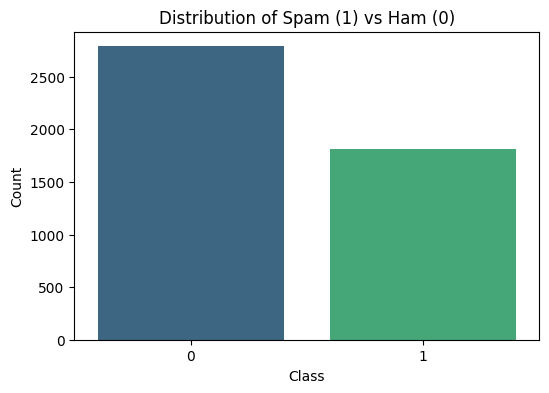

spam
0    60.595523
1    39.404477
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x='spam', data=df, palette='viridis')
plt.title('Distribution of Spam (1) vs Ham (0)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Display percentages
print(df['spam'].value_counts(normalize=True) * 100)

## **Boxplot of Key Features**

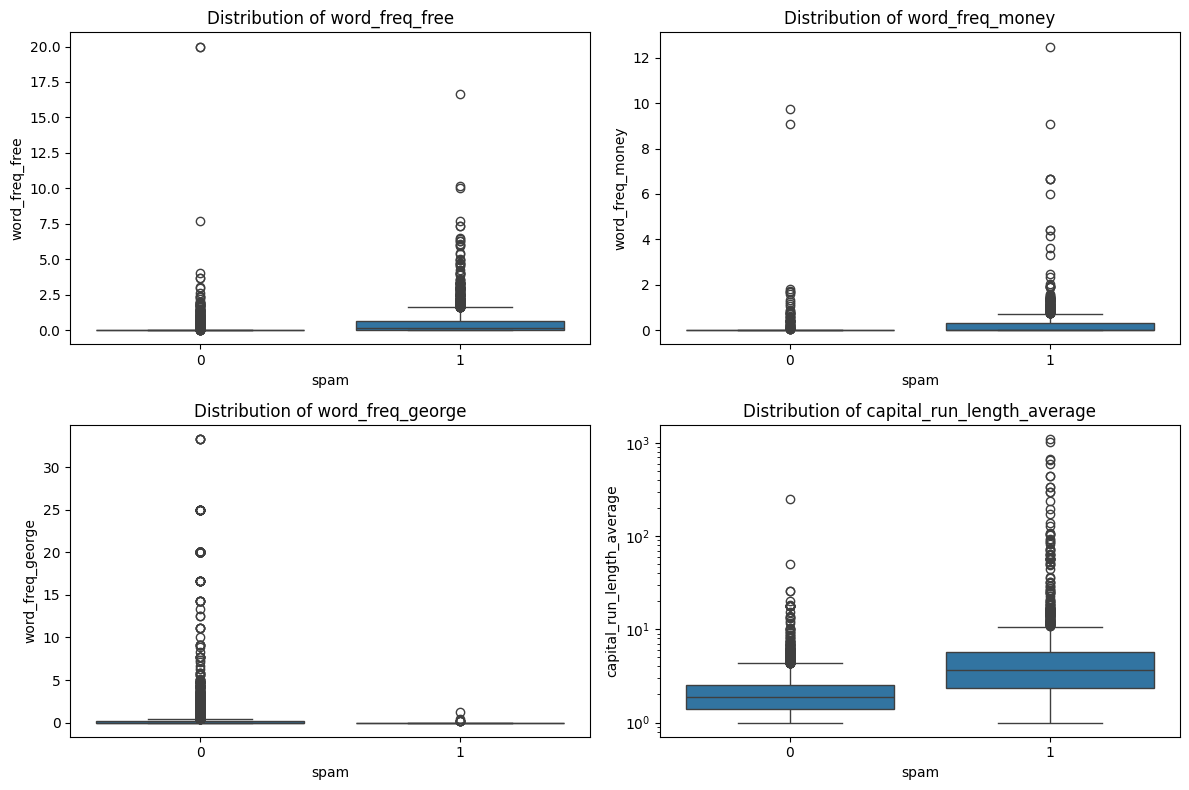

In [6]:
# Selection of features known to be common in spam or ham
selected_features = ['word_freq_free', 'word_freq_money', 'word_freq_george', 'capital_run_length_average']

plt.figure(figsize=(12, 8))
for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='spam', y=col, data=df)
    plt.title(f'Distribution of {col}')
    # Using log scale for run length average due to high variance
    if col == 'capital_run_length_average':
        plt.yscale('log')

plt.tight_layout()
plt.show()

## **Correlation Matrix**

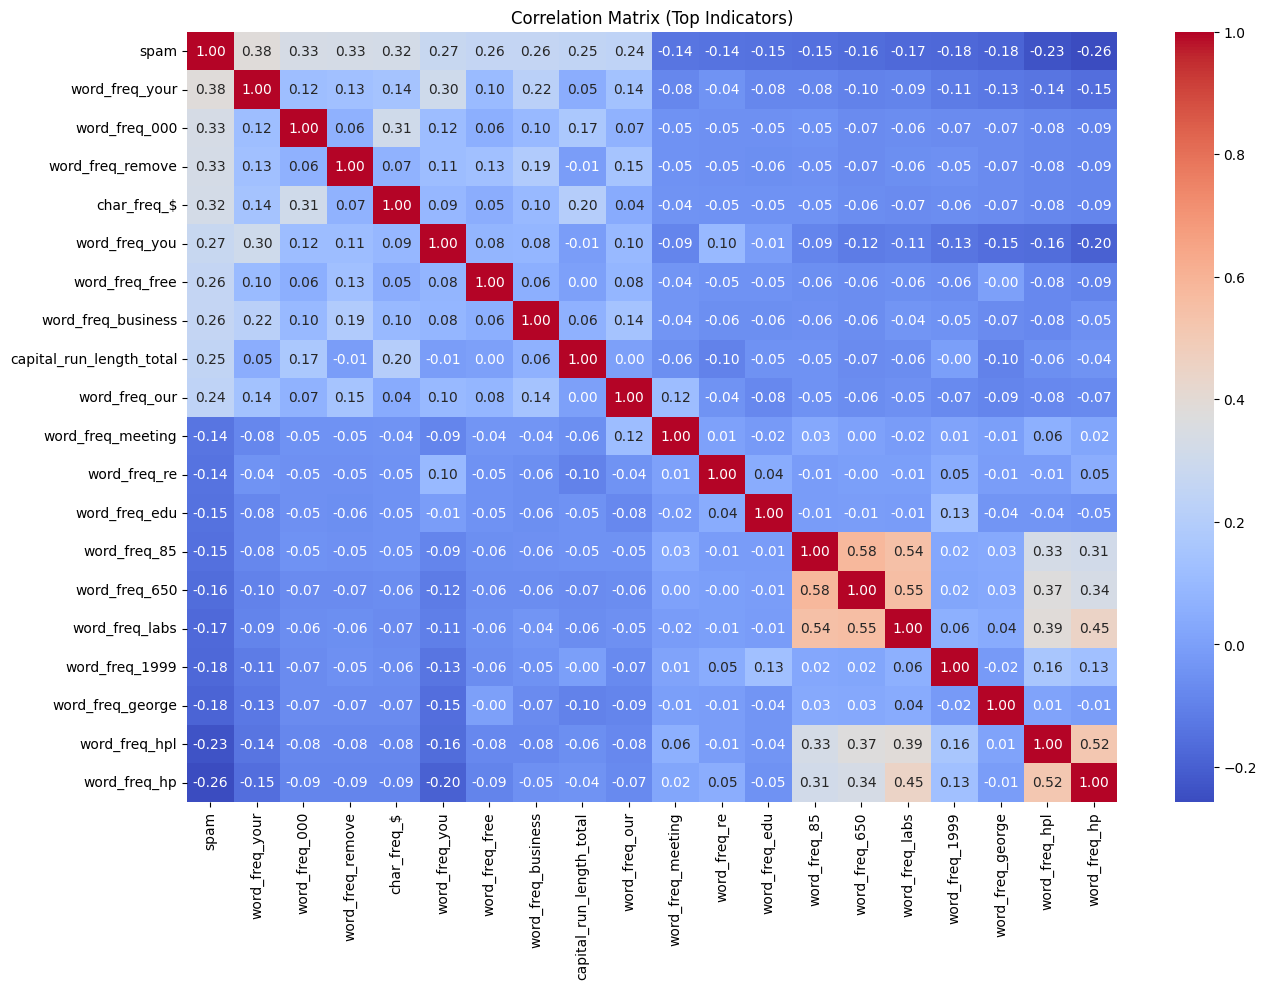

In [7]:
plt.figure(figsize=(15, 10))
# Focusing on the last 20 features for readability, or you can use df.corr() for all
corr = df.corr()
# Get the top correlations with the 'spam' target
top_corr = pd.concat([corr['spam'].sort_values(ascending=False).head(10), corr['spam'].sort_values(ascending=False).tail(10)])

sns.heatmap(df[top_corr.index].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (Top Indicators)')
plt.show()

## **Pair Plot**

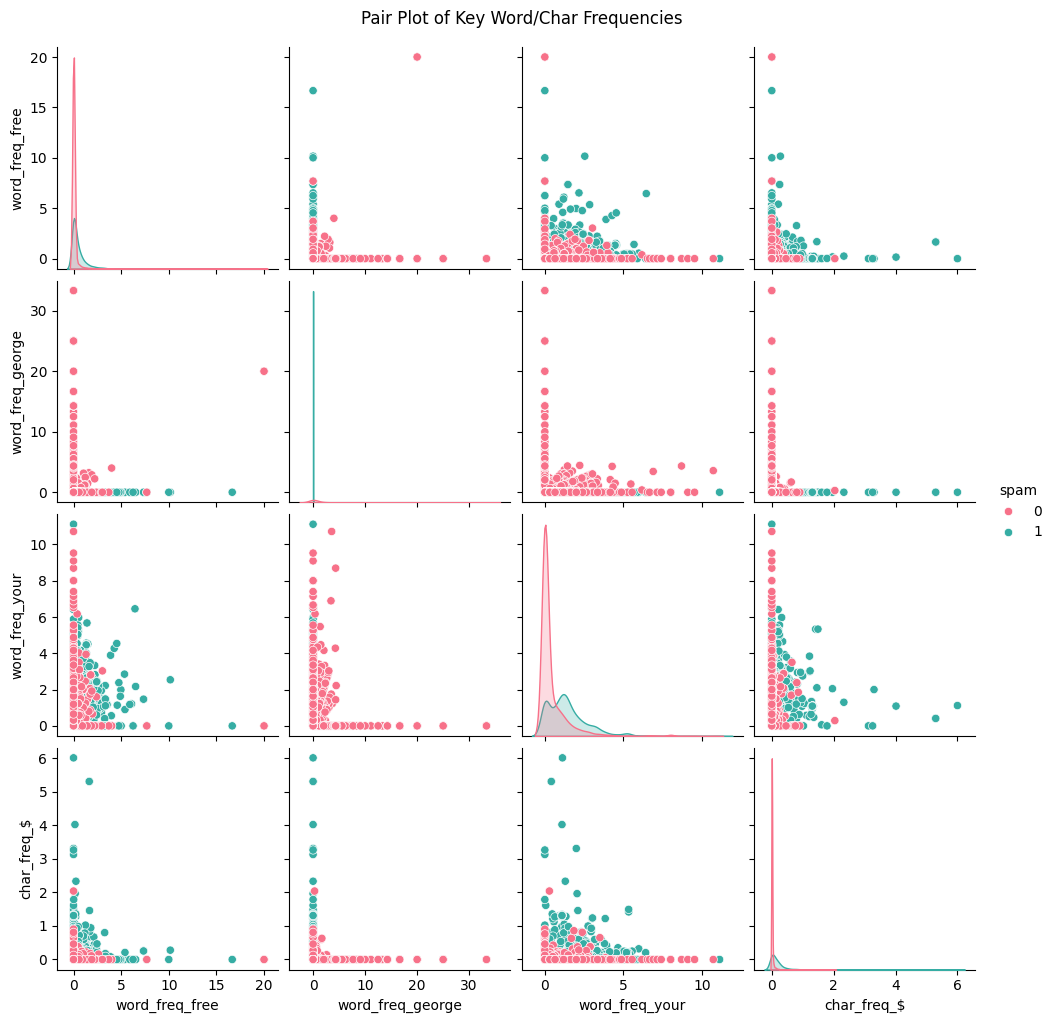

In [8]:
# Subset for visualization
pairplot_features = ['word_freq_free', 'word_freq_george', 'word_freq_your', 'char_freq_$', 'spam']

sns.pairplot(df[pairplot_features], hue='spam', diag_kind='kde', palette='husl')
plt.suptitle('Pair Plot of Key Word/Char Frequencies', y=1.02)
plt.show()

# **Preprocessing**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('spam', axis=1)
y = df['spam']

# Calculate Information Gain
importances = mutual_info_classif(X, y)
top_10_indices = importances.argsort()[-10:][::-1]
top_10_features = X.columns[top_10_indices]

# Prepare Data
X_top10 = X[top_10_features]
X_train, X_test, y_train, y_test = train_test_split(X_top10, y, test_size=0.2, random_state=42, stratify=y)

print(f"Top 10 Features: {list(top_10_features)}")

Top 10 Features: ['char_freq_!', 'capital_run_length_longest', 'char_freq_$', 'capital_run_length_average', 'word_freq_your', 'word_freq_remove', 'capital_run_length_total', 'word_freq_free', 'word_freq_money', 'word_freq_hp']


# **Model Training**

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True, random_state=42)
}

results = []
cms = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Store metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })
    cms[name] = confusion_matrix(y_test, y_pred)

# Display Metrics Table
results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.933768   0.931429  0.898072  0.914446
1  Logistic Regression  0.892508   0.912500  0.804408  0.855051
2                  SVM  0.705755   0.686992  0.465565  0.555008


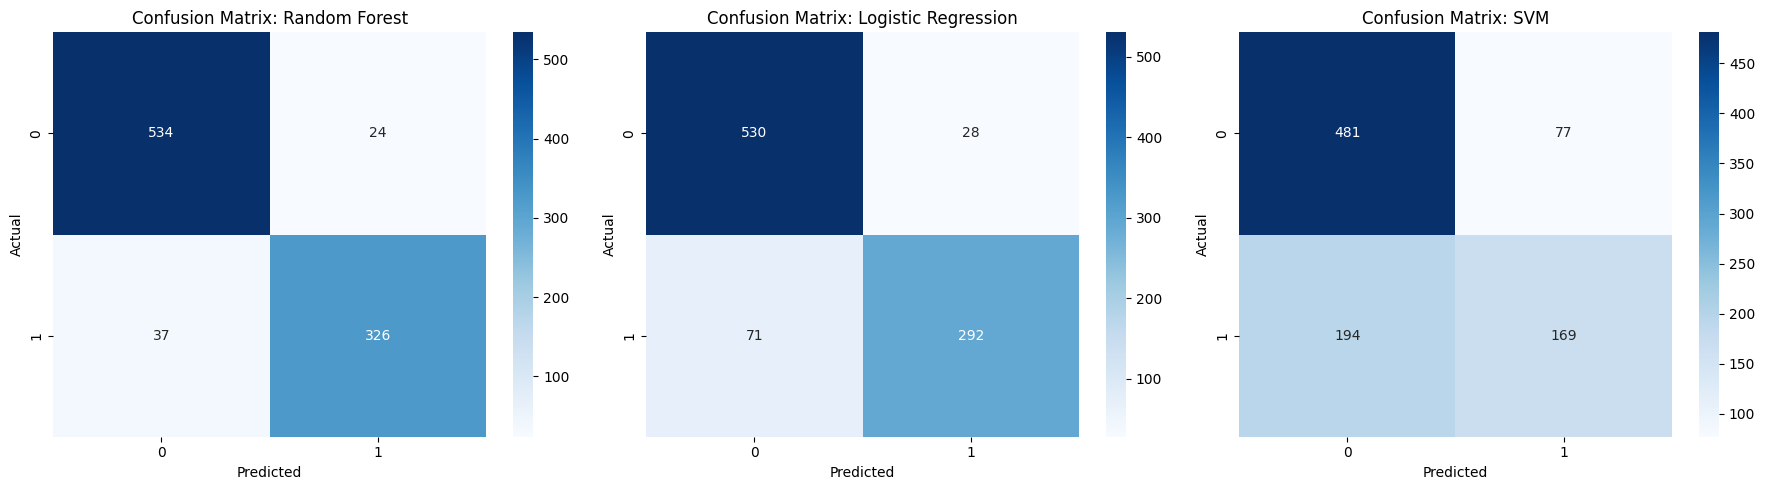

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, matrix) in enumerate(cms.items()):
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Confusion Matrix: {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

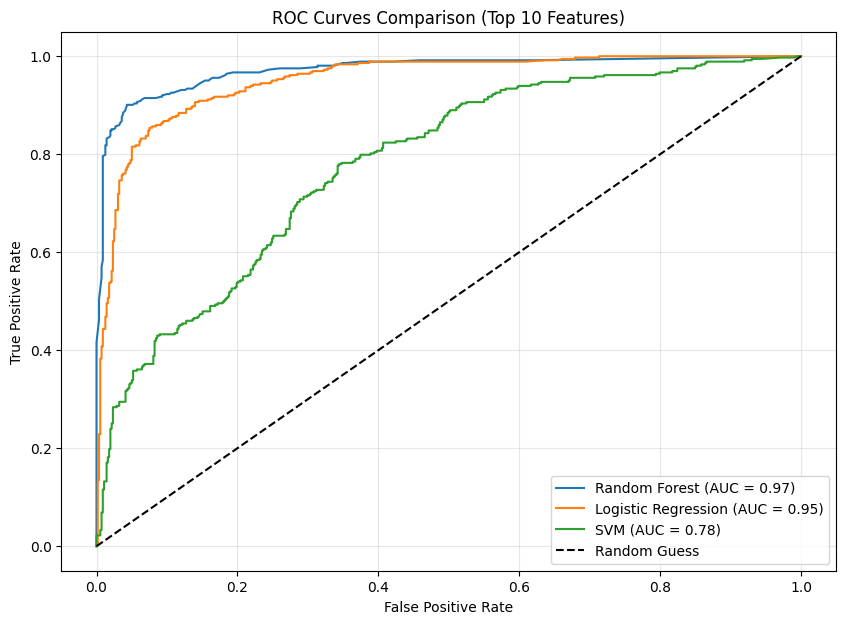

In [12]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Get probability scores for the positive class (spam)
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Top 10 Features)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# **Hyperparameter optimization with RandomizedSearch**

In [13]:
from sklearn.model_selection import RandomizedSearchCV

# Define broader but sampled search spaces
rf_dist = {'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 2]}
lr_dist = {'C': [0.1, 1, 10], 'solver': ['liblinear']} # liblinear is faster for small datasets
svm_dist = {'C': [0.1, 1, 10], 'gamma': ['scale']}

def quick_tune(model, dist, X, y):
    # n_iter=5 means it only tries 5 random combinations per model
    search = RandomizedSearchCV(model, dist, n_iter=5, cv=3, scoring='f1', n_jobs=-1, random_state=42)
    search.fit(X, y)
    return search.best_estimator_

print("Running fast optimization...")
best_rf = quick_tune(RandomForestClassifier(random_state=42), rf_dist, X_train, y_train)
best_lr = quick_tune(LogisticRegression(max_iter=1000), lr_dist, X_train, y_train)
best_svm = quick_tune(SVC(probability=True), svm_dist, X_train, y_train)
print("Optimization complete!")

Running fast optimization...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=5. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Optimization complete!


In [14]:
from sklearn.metrics import precision_recall_fscore_support

models = {"RF": best_rf, "LR": best_lr, "SVM": best_svm}
final_stats = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

    final_stats.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})

performance_df = pd.DataFrame(final_stats)
print(performance_df)

  Model  Accuracy  Precision    Recall        F1
0    RF  0.925081   0.920000  0.887052  0.903226
1    LR  0.891422   0.912226  0.801653  0.853372
2   SVM  0.718784   0.713115  0.479339  0.573311


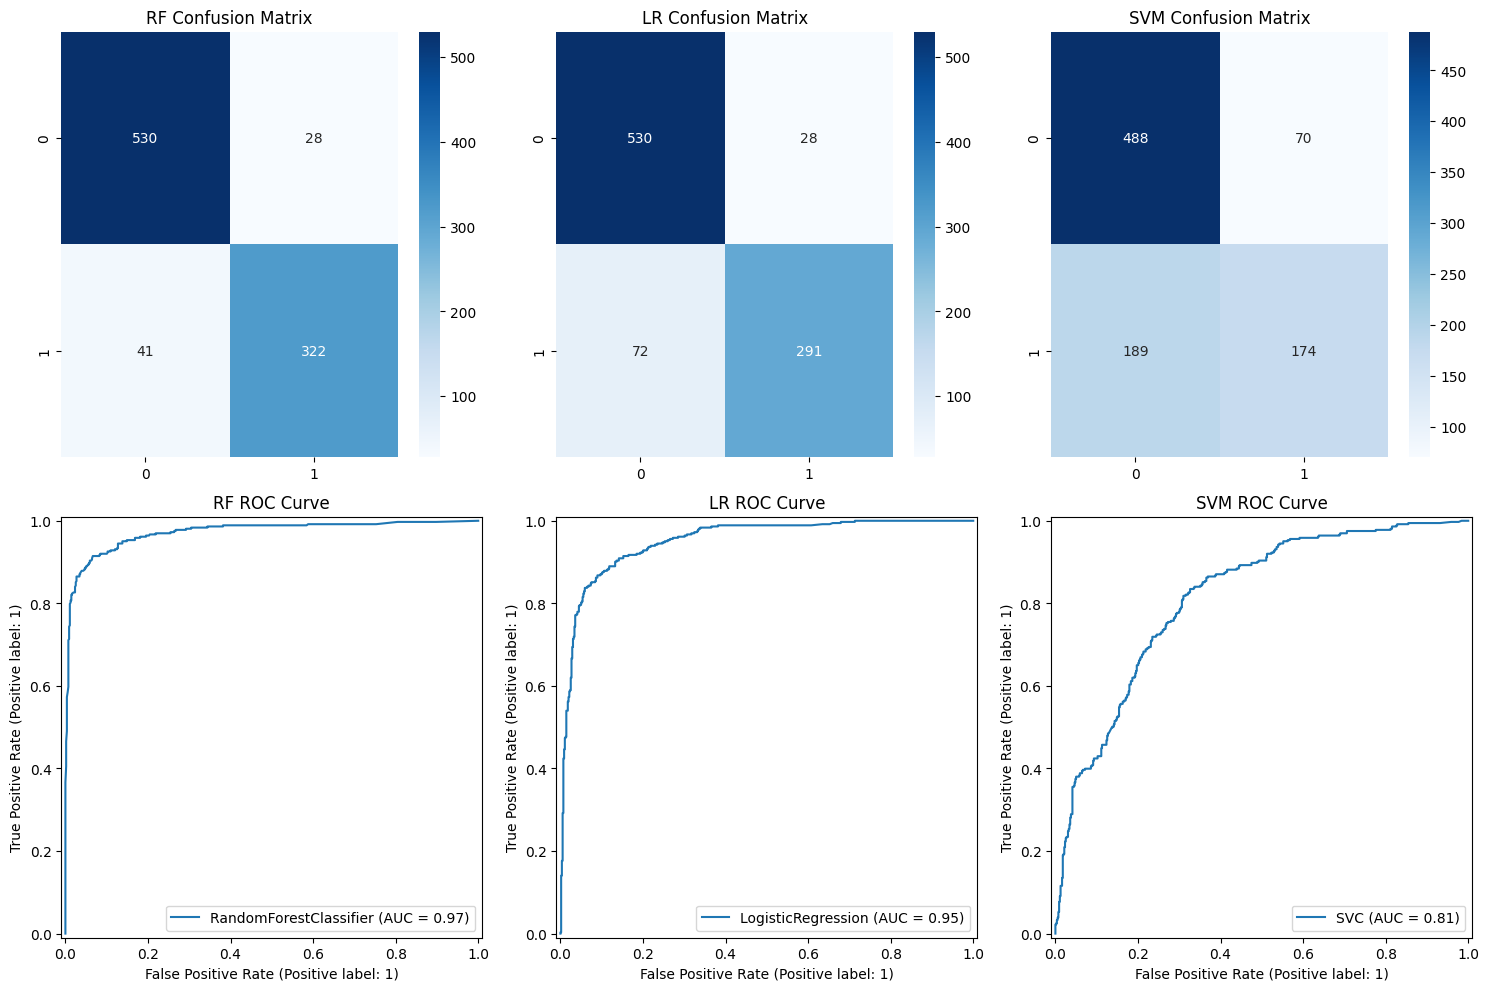

In [15]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (name, model) in enumerate(models.items()):
    # Confusion Matrix (Top Row)
    y_pred = model.predict(X_test)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0, i])
    axes[0, i].set_title(f"{name} Confusion Matrix")

    # ROC Curve (Bottom Row)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1, i])
    axes[1, i].set_title(f"{name} ROC Curve")

plt.tight_layout()
plt.show()

# **K-Fold Cross Validation**

In [16]:
from sklearn.model_selection import cross_validate, KFold
import pandas as pd

# Define the K-Fold strategy (e.g., 5 folds)
# shuffle=True is recommended to ensure data is well-mixed
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define the metrics we want to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = []

for name, model in models.items():
    # Perform cross-validation
    # Note: We use X and y (the full dataset) here as CV handles the splitting
    cv_scores = cross_validate(model, X, y, cv=kf, scoring=scoring)

    # Store the mean and standard deviation of each metric
    cv_results.append({
        "Model": name,
        "Accuracy (Mean)": cv_scores['test_accuracy'].mean(),
        "Accuracy (Std)":  cv_scores['test_accuracy'].std(),
        "Precision (Mean)": cv_scores['test_precision'].mean(),
        "Recall (Mean)":    cv_scores['test_recall'].mean(),
        "F1-Score (Mean)":  cv_scores['test_f1'].mean()
    })

# Display the Cross-Validation results
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df)

  Model  Accuracy (Mean)  Accuracy (Std)  Precision (Mean)  Recall (Mean)  \
0    RF         0.950879        0.003922          0.952457       0.921099   
1    LR         0.927191        0.003915          0.921431       0.891559   
2   SVM         0.735713        0.010272          0.752152       0.491672   

   F1-Score (Mean)  
0         0.936444  
1         0.906125  
2         0.594428  


# **Training with Penalized Loss (Class Weights)**

In [17]:
from sklearn.metrics import confusion_matrix, roc_curve

# Define models with heavy penalty on False Positives (Class 0)
# 'balanced' is standard, but {0: 10, 1: 1} is an explicit high penalty
penalized_rf = RandomForestClassifier(n_estimators=100, class_weight={0: 10, 1: 1}, random_state=42)
penalized_lr = LogisticRegression(class_weight={0: 10, 1: 1}, max_iter=1000)

# Fit models
penalized_rf.fit(X_train, y_train)
penalized_lr.fit(X_train, y_train)

print("Models trained with high penalty for False Positives.")

Models trained with high penalty for False Positives.


In [18]:
def get_fpr(model, X, y):
    y_pred = model.predict(X)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    fpr = fp / (fp + tn)
    return fpr

# Comparing Random Forest (using the best_rf from previous step vs penalized)
print(f"Standard RF False Positive Rate: {get_fpr(best_rf, X_test, y_test):.4f}")
print(f"Penalized RF False Positive Rate: {get_fpr(penalized_rf, X_test, y_test):.4f}")

Standard RF False Positive Rate: 0.0502
Penalized RF False Positive Rate: 0.0502


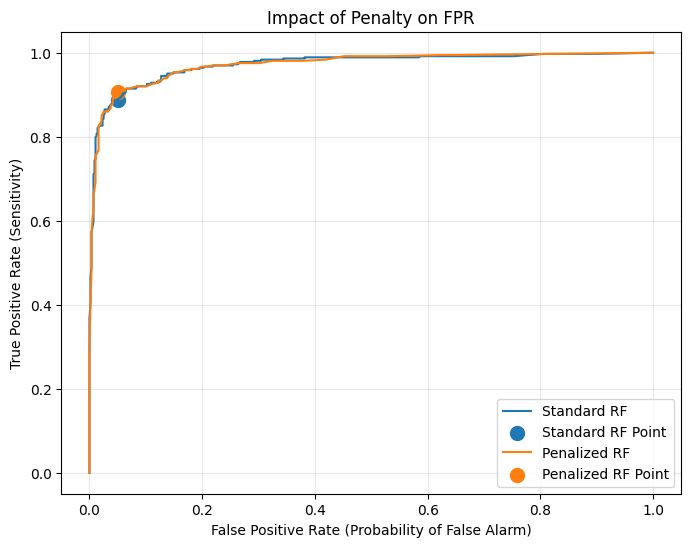

In [19]:
plt.figure(figsize=(8, 6))

for name, model in {"Standard RF": best_rf, "Penalized RF": penalized_rf}.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=name)

    # Mark the specific operating point (default threshold 0.5)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    current_fpr = fp / (fp + tn)
    current_tpr = tp / (tp + fn)
    plt.scatter(current_fpr, current_tpr, s=100, label=f'{name} Point')

plt.xlabel('False Positive Rate (Probability of False Alarm)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Impact of Penalty on FPR')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Model Interpretability with SHAP**

Generating SHAP Summary Plot...


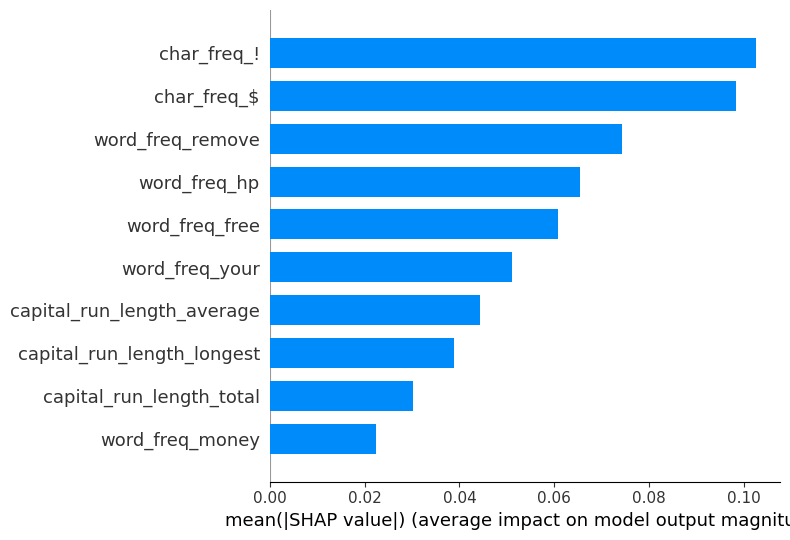

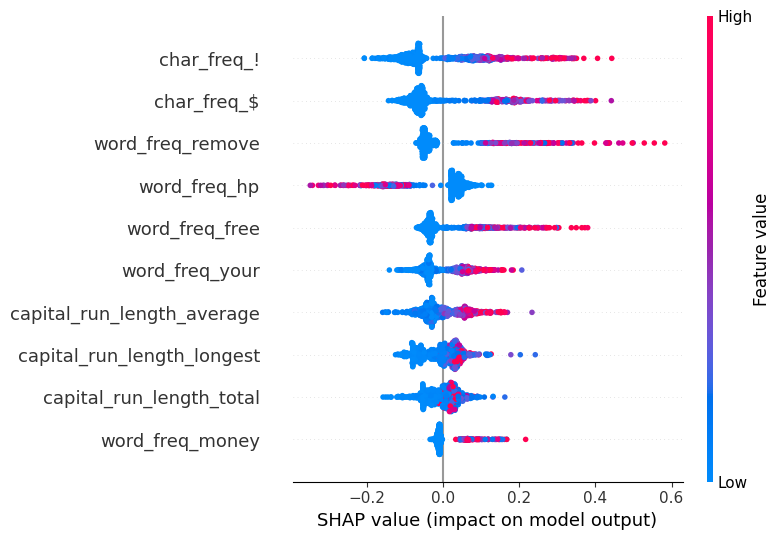

In [21]:
import shap

# 1. Initialize the SHAP explainer with your best Random Forest model
explainer = shap.TreeExplainer(best_rf)

# 2. Calculate SHAP values for the test set
# This explains how much each feature contributed to the prediction
shap_values = explainer.shap_values(X_test)

# 3. Visualize the global importance
# The summary plot shows which features are most influential across the whole dataset
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")

# 4. Detailed Feature Influence
# This shows not just importance, but whether high values of a feature
# (like many '!' marks) increase or decrease the spam probability.
shap.summary_plot(shap_values[:, :, 1], X_test)